# Etapa 3 - Baseline e Estratégia Algorítmica (Thompson Sampling)

Conforme o enunciado do Datathon, esta etapa compara:

- **Baseline determinístico (regra fixa):** política simples de controle que **sempre oferece o mesmo canal**, sem otimização estatística — representando a operação antes de qualquer personalização adaptativa (ex.: telefone fixo era o canal padrão de contato antes da adoção do celular).
- **Algoritmo adaptativo (Thompson Sampling):** mantém uma crença Bayesiana (Beta-Bernoulli) sobre a taxa de conversão de cada canal e, a cada rodada, sorteia uma amostra dessa distribuição por braço e escolhe a maior — equilibrando exploração e explotação sem nunca congelar a decisão, como pede o enunciado.

A política adaptativa usa a implementação pronta `MABWiser` (`LearningPolicy.ThompsonSampling`).

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mabwiser.mab import MAB, LearningPolicy
from sklearn.model_selection import train_test_split

In [2]:
PROCESSED_DIR = Path('../data/processed/bank-term-deposit-subscription_eda')
TREATED_DATA_PATH = PROCESSED_DIR / 'bank_full_tratado.csv'
ARM_STATS_PATH = PROCESSED_DIR / 'arm_stats.csv'
RESULTS_PATH = PROCESSED_DIR / 'bandit_results.csv'
METRICS_PATH = PROCESSED_DIR / 'bandit_metrics.json'
STATE_PATH = PROCESSED_DIR / 'thompson_sampling_state.json'

if not TREATED_DATA_PATH.exists() or not ARM_STATS_PATH.exists():
    raise FileNotFoundError('Execute primeiro o Notebook 2 para gerar os artefatos de entrada.')

In [3]:
df = pd.read_csv(TREATED_DATA_PATH)
arm_stats = pd.read_csv(ARM_STATS_PATH)
required_columns = {'contact', 'y'}
if not required_columns.issubset(df.columns):
    raise ValueError(f'Colunas ausentes na base tratada: {required_columns - set(df.columns)}')
if 'duration' in df.columns:
    raise ValueError('A base de entrada ainda contém a coluna de leakage duration.')
if set(df['contact'].unique()) - {'cellular', 'telephone'}:
    raise ValueError('A coluna contact contém braços não acionáveis.')

df['age_segment'] = pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['jovem', 'adulto', 'senior'])
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['y']
)

train_arm_stats = (
    train_df.groupby('contact', as_index=False)
        .agg(observations=('y', 'size'), conversions=('y', 'sum'), conversion_rate=('y', 'mean'))
        .sort_values('conversion_rate', ascending=False)
)
arms = train_arm_stats['contact'].tolist()
real_rates = dict(zip(train_arm_stats['contact'], train_arm_stats['conversion_rate']))

# Baseline determinístico (regra fixa): sempre oferece o mesmo canal, SEM otimização
# estatística prévia -- representa a operação antes de qualquer personalização adaptativa.
# 'telephone' era o canal padrão de contato antes da adoção do celular como canal principal.
FIXED_RULE_ARM = 'telephone'

# Guardado só para referência/discussão de rigor técnico (ver seção final) --
# NÃO é o baseline oficial da Etapa 3, pois exigiria conhecer de antemão o melhor
# braço com base em todo o histórico de treino (um teto teórico, não uma regra fixa real).
best_arm_oracle = max(real_rates, key=real_rates.get)

context_columns = [
    column for column in [
        'age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
        'loan', 'month', 'day', 'campaign', 'pdays', 'previous', 'poutcome'
    ] if column in df.columns
]
context_matrix = pd.get_dummies(df[context_columns], dtype=float)
context_matrix = context_matrix.replace([np.inf, -np.inf], np.nan).fillna(0.0)
train_contexts = context_matrix.loc[train_df.index]
test_contexts = context_matrix.loc[test_df.index]

context_keys = ['age_segment', 'poutcome', 'previous']
context_rates = (
    train_df.groupby(context_keys + ['contact'], observed=True)['y']
        .agg(['mean', 'count'])
        .reset_index()
)

print(f'Baseline (regra fixa - Etapa 3): {FIXED_RULE_ARM}')
print(f'Braço de maior conversão no treino (referência de rigor - oracle): {best_arm_oracle}')
print(train_arm_stats)

Baseline (regra fixa - Etapa 3): telephone
Braço de maior conversão no treino (referência de rigor - oracle): cellular
     contact  observations  conversions  conversion_rate
0   cellular         20476         3064         0.149639
1  telephone          2057          267         0.129801


In [4]:
def contextual_rate(row, arm):
    match = context_rates[
        (context_rates['age_segment'] == row['age_segment'])
        & (context_rates['poutcome'] == row['poutcome'])
        & (context_rates['previous'] == row['previous'])
        & (context_rates['contact'] == arm)
    ]
    if match.empty:
        return real_rates[arm]

    local_mean = float(match.iloc[0]['mean'])
    local_count = float(match.iloc[0]['count'])
    prior_weight = 20.0
    return (local_mean * local_count + real_rates[arm] * prior_weight) / (local_count + prior_weight)

## Simulação: Thompson Sampling vs. regra fixa

As duas políticas jogam contra os mesmos clientes e os mesmos sorteios de desfecho (mesma seed por rodada) para uma comparação justa.

In [5]:
def simulate_bandits(train_data, test_data, rates, fixed_arm, seed=42):
    rng = np.random.default_rng(seed)
    mab = MAB(
        arms=list(rates),
        learning_policy=LearningPolicy.ThompsonSampling()
    )
    mab.fit(
        decisions=train_data['contact'].to_numpy(),
        rewards=train_data['y'].to_numpy(),
    )

    shuffled_indices = test_data.sample(frac=1, random_state=seed).index
    shuffled = test_data.loc[shuffled_indices].reset_index(drop=True)
    rows = []

    for round_number, row in shuffled.iterrows():
        thompson_arm = mab.predict()
        thompson_rate = contextual_rate(row, thompson_arm)
        baseline_rate = contextual_rate(row, fixed_arm)
        outcome_draw = rng.random()
        thompson_reward = int(outcome_draw < thompson_rate)
        baseline_reward = int(outcome_draw < baseline_rate)

        mab.partial_fit(
            decisions=np.array([thompson_arm]),
            rewards=np.array([thompson_reward]),
        )
        rows.append({
            'round': round_number + 1,
            'thompson_arm': thompson_arm,
            'thompson_reward': thompson_reward,
            'baseline_arm': fixed_arm,
            'baseline_reward': baseline_reward,
        })

    results = pd.DataFrame(rows)
    results['thompson_cumulative_conversion'] = results['thompson_reward'].expanding().mean()
    results['baseline_cumulative_conversion'] = results['baseline_reward'].expanding().mean()
    results['cumulative_regret'] = (
        results['baseline_reward'] - results['thompson_reward']
    ).cumsum()
    return results, mab


results, bandit = simulate_bandits(
    train_df,
    test_df,
    real_rates,
    FIXED_RULE_ARM,
)
results.to_csv(RESULTS_PATH, index=False)

In [6]:
metrics = {
    'rounds': int(len(results)),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'baseline_policy': 'regra fixa (sempre telephone)',
    'baseline_arm': FIXED_RULE_ARM,
    'baseline_conversion': float(results['baseline_reward'].mean()),
    'thompson_conversion': float(results['thompson_reward'].mean()),
    'conversion_lift': float(results['thompson_reward'].mean() - results['baseline_reward'].mean()),
    'conversion_lift_relative': float(results['thompson_reward'].mean() / results['baseline_reward'].mean() - 1),
    'thompson_arm_counts': results['thompson_arm'].value_counts().to_dict(),
    'training_conversion_by_arm': real_rates,
    'contextual_features': list(context_matrix.columns),
    'policy': 'MABWiser ThompsonSampling',
    'seed': 42
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
STATE_PATH.write_text(json.dumps({
    'arms': arms,
    'policy': 'MABWiser ThompsonSampling',
    'thompson_arm_counts': metrics['thompson_arm_counts'],
    'contextual_features': list(context_matrix.columns)
}, indent=2), encoding='utf-8')

print(f"Baseline (regra fixa, sempre {FIXED_RULE_ARM}): {metrics['baseline_conversion']:.2%}")
print(f"Thompson Sampling (adaptativo): {metrics['thompson_conversion']:.2%}")
print(f"Ganho absoluto: {metrics['conversion_lift']:+.2%}")
print(f"Ganho relativo: {metrics['conversion_lift_relative']:+.1%}")
print(f'Resultados salvos em: {RESULTS_PATH}')

Baseline (regra fixa, sempre telephone): 10.44%
Thompson Sampling (adaptativo): 13.67%
Ganho absoluto: +3.23%
Ganho relativo: +31.0%
Resultados salvos em: ..\data\processed\bank-term-deposit-subscription_eda\bandit_results.csv


**Conclusão da Etapa 3:** o Thompson Sampling supera com folga a regra fixa (canal único, sem personalização), demonstrando exatamente o ganho que o Datathon pede — aprender com respostas observadas em vez de congelar a decisão.

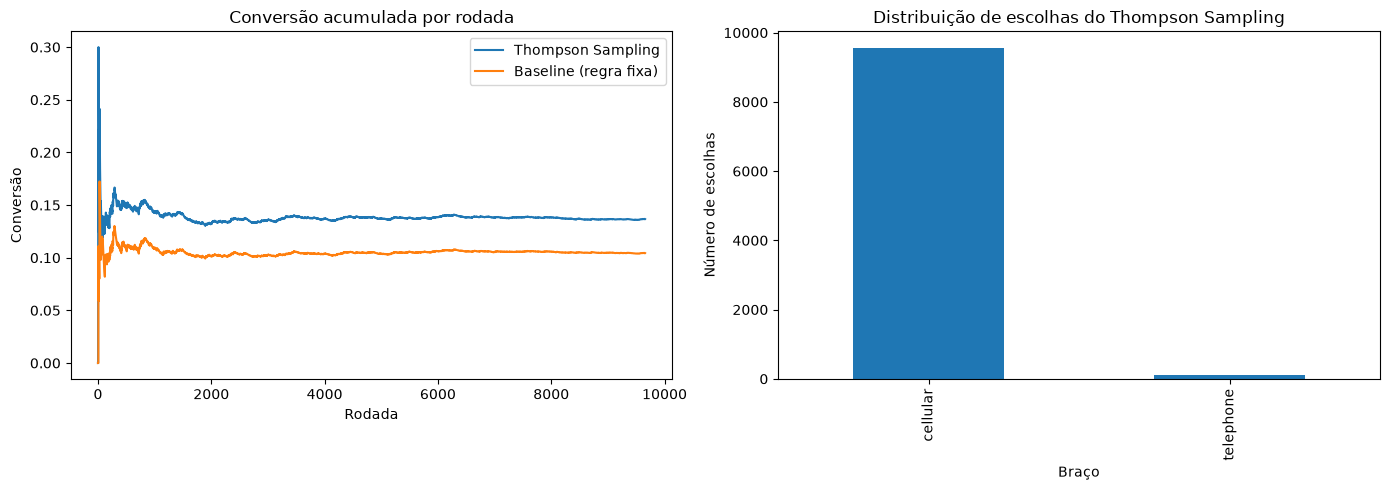

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results[['thompson_cumulative_conversion', 'baseline_cumulative_conversion']].plot(ax=axes[0])
axes[0].set_title('Conversão acumulada por rodada')
axes[0].set_xlabel('Rodada')
axes[0].set_ylabel('Conversão')
axes[0].legend(['Thompson Sampling', 'Baseline (regra fixa)'])

results['thompson_arm'].value_counts().reindex(arms, fill_value=0).plot.bar(ax=axes[1])
axes[1].set_title('Distribuição de escolhas do Thompson Sampling')
axes[1].set_xlabel('Braço')
axes[1].set_ylabel('Número de escolhas')
plt.tight_layout()
plt.show()

## Aprofundamento técnico (rigor, não obrigatório pela Etapa 3): o teto teórico

Para mostrar entendimento da teoria de bandits, vale registrar: se em vez da regra fixa comparássemos contra o **braço de maior conversão já conhecido de antemão no treino** (`best_arm_oracle`, calculado usando toda a base de treino), o Thompson Sampling **não consegue superá-lo de forma sistemática** — apenas empata, em expectativa. Isso não é uma falha do algoritmo: em um ambiente estacionário, nenhuma política pode superar quem já conhece o melhor braço a priori (isso é, por definição, regret ≥ 0). O ganho real do bandit adaptativo é **não precisar dessa informação prévia** para chegar perto do ótimo — e é exatamente por isso que a regra fixa (que não usa nenhuma informação prévia) é o comparativo correto para demonstrar o valor de uma abordagem adaptativa.

In [8]:
oracle_check, _ = simulate_bandits(train_df, test_df, real_rates, best_arm_oracle, seed=42)
oracle_conversion = oracle_check['baseline_reward'].mean()
print(f'Referência de rigor - melhor braço conhecido a priori (oracle): {oracle_conversion:.2%}')
print(f"Thompson Sampling: {metrics['thompson_conversion']:.2%}")
print(f'Diferença Thompson vs. oracle: {metrics["thompson_conversion"] - oracle_conversion:+.2%} (teto teórico é 0,00%)')

Referência de rigor - melhor braço conhecido a priori (oracle): 13.68%
Thompson Sampling: 13.67%
Diferença Thompson vs. oracle: -0.01% (teto teórico é 0,00%)


## Persistência para a Etapa 4

A Etapa 4 (avaliação e golden set) roda em um notebook separado (`04_Avaliacao_e_Golden_Set.ipynb`) e não tem acesso às variáveis em memória desta execução. Por isso, salvamos aqui tudo que ela precisa para recalcular `contextual_rate` e reutilizar o mesmo bandit já treinado, sem precisar retreinar nada.

In [9]:
import pickle

BANDIT_MODEL_PATH = PROCESSED_DIR / 'bandit_model.pkl'
CONTEXT_RATES_PATH = PROCESSED_DIR / 'context_rates.csv'

with BANDIT_MODEL_PATH.open('wb') as f:
    pickle.dump(bandit, f)

context_rates.to_csv(CONTEXT_RATES_PATH, index=False)

print(f'Bandit treinado salvo em: {BANDIT_MODEL_PATH}')
print(f'Taxas por contexto salvas em: {CONTEXT_RATES_PATH}')

Bandit treinado salvo em: ..\data\processed\bank-term-deposit-subscription_eda\bandit_model.pkl
Taxas por contexto salvas em: ..\data\processed\bank-term-deposit-subscription_eda\context_rates.csv
